In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import warnings
import json
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/preprocessed_data.csv', parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

print(f"Data loaded: {len(df)} rows")
print(f"Columns: {len(df.columns)}")

Data loaded: 44534 rows
Columns: 41


In [2]:
sensor = 'Volume Flow RateRMS'

normal_data = df[df['anomaly'] == 0.0][sensor].values
full_data = df[sensor].values

print(f"Selected sensor: {sensor}")
print(f"Normal data points: {len(normal_data)}")
print(f"Total data points: {len(full_data)}")

print("\nADF Stationarity Test on normal data:")
adf_result = adfuller(normal_data)
print(f"ADF Statistic: {round(adf_result[0], 4)}")
print(f"P-value: {round(adf_result[1], 6)}")
print(f"Critical values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {round(value, 4)}")

if adf_result[1] < 0.05:
    print("\nResult: Series IS stationary (p < 0.05)")
    print("We can fit ARIMA without differencing (d=0)")
else:
    print("\nResult: Series is NOT stationary (p >= 0.05)")
    print("We need differencing (d=1)")

Selected sensor: Volume Flow RateRMS
Normal data points: 32262
Total data points: 44534

ADF Stationarity Test on normal data:
ADF Statistic: -1.6185
P-value: 0.473491
Critical values:
  1%: -3.4306
  5%: -2.8616
  10%: -2.5668

Result: Series is NOT stationary (p >= 0.05)
We need differencing (d=1)


In [3]:
train_size = 2000
train_data = normal_data[:train_size]

print(f"Training ARIMA on {train_size} normal data points...")
print("ARIMA parameters: p=1, d=1, q=1")
print("p=1: uses 1 previous value (autoregression)")
print("d=1: differences once (makes stationary)")
print("q=1: uses 1 previous error (moving average)")

arima_model = ARIMA(train_data, order=(1, 1, 1))
arima_fitted = arima_model.fit()

print("\nARIMA model fitted successfully")
print(f"\nModel summary:")
print(f"AIC score: {round(arima_fitted.aic, 4)}")
print(f"BIC score: {round(arima_fitted.bic, 4)}")
print("\nLower AIC = better model fit")

Training ARIMA on 2000 normal data points...
ARIMA parameters: p=1, d=1, q=1
p=1: uses 1 previous value (autoregression)
d=1: differences once (makes stationary)
q=1: uses 1 previous error (moving average)

ARIMA model fitted successfully

Model summary:
AIC score: -12983.1155
BIC score: -12966.3143

Lower AIC = better model fit


Generating in-sample predictions on training data...
Residual mean: -0.000138
Residual std: 0.009393
Residual min: -0.044836
Residual max: 0.031589


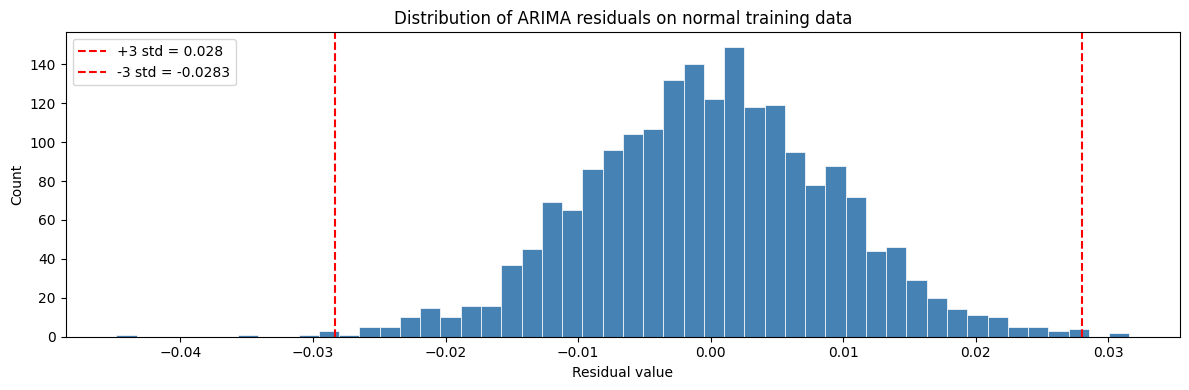

Chart saved to report folder


In [4]:
print("Generating in-sample predictions on training data...")

predictions_train = arima_fitted.fittedvalues

residuals_train = train_data[1:] - predictions_train[1:]

residual_mean = np.mean(residuals_train)
residual_std = np.std(residuals_train)

print(f"Residual mean: {round(residual_mean, 6)}")
print(f"Residual std: {round(residual_std, 6)}")
print(f"Residual min: {round(residuals_train.min(), 6)}")
print(f"Residual max: {round(residuals_train.max(), 6)}")

plt.figure(figsize=(12, 4))
plt.hist(residuals_train, bins=50, color='steelblue', 
         edgecolor='white', linewidth=0.5)
plt.axvline(x=residual_mean + 3*residual_std, 
            color='red', linestyle='--', 
            linewidth=1.5, label=f'+3 std = {round(residual_mean + 3*residual_std, 4)}')
plt.axvline(x=residual_mean - 3*residual_std, 
            color='red', linestyle='--',
            linewidth=1.5, label=f'-3 std = {round(residual_mean - 3*residual_std, 4)}')
plt.title('Distribution of ARIMA residuals on normal training data')
plt.xlabel('Residual value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../report/arima_residuals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to report folder")

## ARIMA residual distribution

Residuals from ARIMA(1,1,1) fitted on normal training data 
follow an approximately normal distribution centered at zero.

This confirms that ARIMA successfully learned the temporal 
pattern of normal Volume Flow RateRMS behavior.

Anomaly threshold set at mean ± 3 standard deviations:
- Upper threshold: +0.028
- Lower threshold: -0.028

Any future reading producing a residual outside this range 
is flagged as anomalous — statistically unlikely under 
normal operating conditions.

In [5]:
print("Computing ARIMA residuals with rolling window...")
print("Refitting every 200 rows - this takes 3-5 minutes...")

full_series = df[sensor].values
n = len(full_series)
arima_residuals = np.zeros(n)

train_size = 2000
refit_every = 200

current_model = None

for i in range(train_size, n):
    if (i - train_size) % refit_every == 0:
        window = full_series[i-train_size:i]
        try:
            current_model = ARIMA(window, order=(1,1,1)).fit()
        except:
            pass
    
    if current_model is not None:
        try:
            forecast = current_model.forecast(steps=1)[0]
            arima_residuals[i] = full_series[i] - forecast
        except:
            arima_residuals[i] = 0
    
    if i % 5000 == 0:
        print(f"Progress: {i}/{n} rows done...")

upper_threshold = residual_mean + 3 * residual_std
lower_threshold = residual_mean - 3 * residual_std

predictions_arima = (
    (arima_residuals > upper_threshold) |
    (arima_residuals < lower_threshold)
).astype(int)

predictions_arima[:train_size] = 0

print(f"\nDone")
print(f"Upper threshold: {round(upper_threshold, 6)}")
print(f"Lower threshold: {round(lower_threshold, 6)}")
print(f"Total anomalies detected: {predictions_arima.sum()}")
print(f"Total actual anomalies: {int(df['anomaly'].sum())}")
print(f"Detection rate: {round(predictions_arima.sum() / df['anomaly'].sum() * 100, 2)}%")

Computing ARIMA residuals with rolling window...
Refitting every 200 rows - this takes 3-5 minutes...
Progress: 5000/44534 rows done...
Progress: 10000/44534 rows done...
Progress: 15000/44534 rows done...
Progress: 20000/44534 rows done...
Progress: 25000/44534 rows done...
Progress: 30000/44534 rows done...
Progress: 35000/44534 rows done...
Progress: 40000/44534 rows done...

Done
Upper threshold: 0.02804
Lower threshold: -0.028317
Total anomalies detected: 6958
Total actual anomalies: 12272
Detection rate: 56.7%


In [6]:
y_true = df['anomaly'].astype(int)
y_pred_arima = predictions_arima.astype(int)

precision_arima = precision_score(y_true, y_pred_arima, zero_division=0)
recall_arima = recall_score(y_true, y_pred_arima, zero_division=0)
f1_arima = f1_score(y_true, y_pred_arima, zero_division=0)
cm_arima = confusion_matrix(y_true, y_pred_arima)

print("=" * 40)
print("ARIMA MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"Sensor: Volume Flow RateRMS")
print(f"ARIMA order: (1, 1, 1)")
print(f"Window size: 2000")
print(f"Refit every: 200 rows")
print()
print(f"Precision:  {round(precision_arima, 4)}")
print(f"Recall:     {round(recall_arima, 4)}")
print(f"F1 Score:   {round(f1_arima, 4)}")
print()
print("Confusion Matrix:")
print(f"  True Negatives:  {cm_arima[0][0]}")
print(f"  False Positives: {cm_arima[0][1]}")
print(f"  False Negatives: {cm_arima[1][0]}")
print(f"  True Positives:  {cm_arima[1][1]}")

ARIMA MODEL EVALUATION RESULTS
Sensor: Volume Flow RateRMS
ARIMA order: (1, 1, 1)
Window size: 2000
Refit every: 200 rows

Precision:  0.4838
Recall:     0.2743
F1 Score:   0.3501

Confusion Matrix:
  True Negatives:  28670
  False Positives: 3592
  False Negatives: 8906
  True Positives:  3366


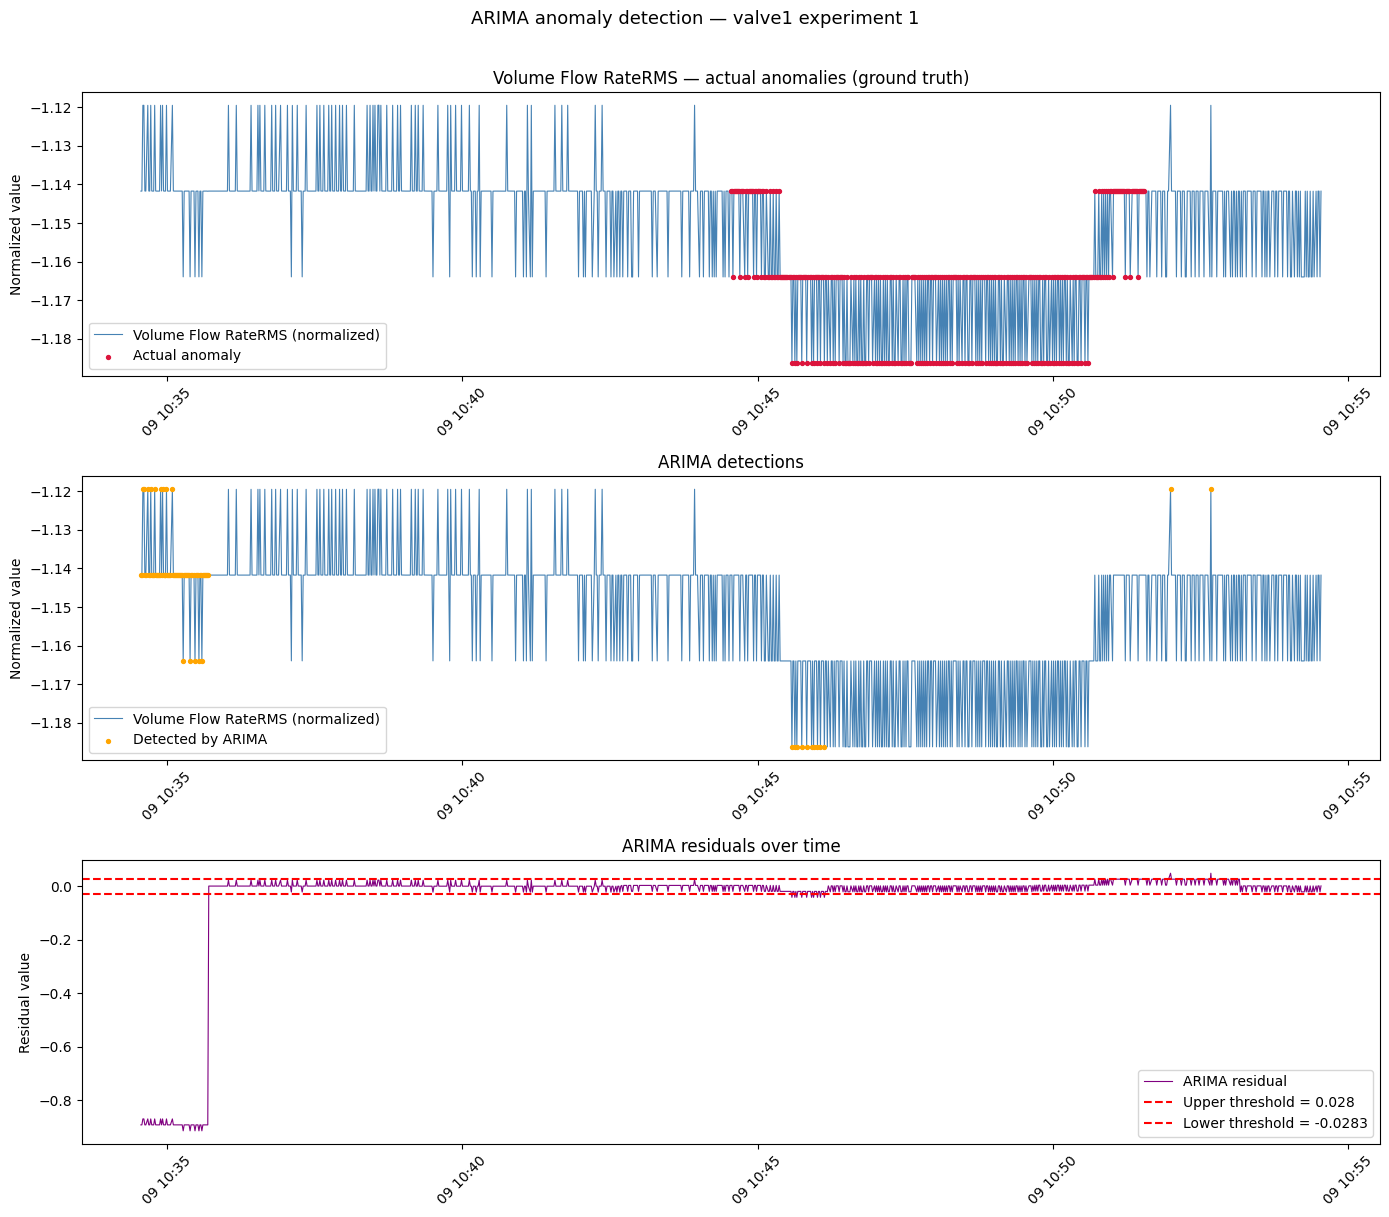

Chart saved to report folder


In [7]:
sample_mask = (df['filename'] == '1.csv') & (df['anomaly_source'] == 'valve1')
sample = df[sample_mask].copy()
sample_residuals = arima_residuals[sample_mask.values]
sample_preds = predictions_arima[sample_mask.values]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(sample['datetime'], sample[sensor],
             color='steelblue', linewidth=0.8, label=f'{sensor} (normalized)')
actual_anomalies = sample[sample['anomaly'] == 1.0]
axes[0].scatter(actual_anomalies['datetime'], actual_anomalies[sensor],
                color='crimson', s=8, zorder=5, label='Actual anomaly')
axes[0].set_title(f'{sensor} — actual anomalies (ground truth)')
axes[0].set_ylabel('Normalized value')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(sample['datetime'], sample[sensor],
             color='steelblue', linewidth=0.8, label=f'{sensor} (normalized)')
detected_mask = sample_preds == 1
detected_times = sample['datetime'].values[detected_mask]
detected_values = sample[sensor].values[detected_mask]
axes[1].scatter(detected_times, detected_values,
                color='orange', s=8, zorder=5, label='Detected by ARIMA')
axes[1].set_title('ARIMA detections')
axes[1].set_ylabel('Normalized value')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(sample['datetime'], sample_residuals,
             color='purple', linewidth=0.8, label='ARIMA residual')
axes[2].axhline(y=upper_threshold, color='red', linestyle='--',
                linewidth=1.5, label=f'Upper threshold = {round(upper_threshold, 4)}')
axes[2].axhline(y=lower_threshold, color='red', linestyle='--',
                linewidth=1.5, label=f'Lower threshold = {round(lower_threshold, 4)}')
axes[2].set_title('ARIMA residuals over time')
axes[2].set_ylabel('Residual value')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('ARIMA anomaly detection — valve1 experiment 1', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../report/arima_detections.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to report folder")

## ARIMA detection analysis

ARIMA detects transition moments — the exact timestamps 
when the signal shifts from one level to another. It 
correctly identifies the onset of the valve closure anomaly 
at 10:44 and the recovery at 10:51.

However ARIMA misses the sustained anomaly period between 
transitions because the rolling window adapts to the new 
signal level, treating it as the new normal baseline.

This reveals a fundamental characteristic of adaptive 
time series models — they detect change points effectively 
but struggle with sustained anomalies once the model 
has adapted to the new pattern.

This contrasts with Z-score which flags all points that 
deviate from the rolling mean regardless of adaptation — 
demonstrating the complementary nature of the two methods.

In [8]:
df['arima_prediction'] = predictions_arima.astype(int)
df['arima_residual'] = arima_residuals

arima_results = {
    'method': 'ARIMA',
    'order': '(1,1,1)',
    'sensor': sensor,
    'window_size': 2000,
    'refit_every': 200,
    'precision': round(precision_arima, 4),
    'recall': round(recall_arima, 4),
    'f1': round(f1_arima, 4),
    'total_detected': int(predictions_arima.sum()),
    'true_positives': int(cm_arima[1][1]),
    'false_positives': int(cm_arima[0][1]),
    'false_negatives': int(cm_arima[1][0]),
    'true_negatives': int(cm_arima[0][0])
}

df.to_csv('../data/preprocessed_data.csv', index=False)

with open('../data/arima_results.json', 'w') as f:
    json.dump(arima_results, f, indent=4)

print("Results saved successfully")
print("\nARIMA final results summary:")
for key, value in arima_results.items():
    print(f"  {key}: {value}")

Results saved successfully

ARIMA final results summary:
  method: ARIMA
  order: (1,1,1)
  sensor: Volume Flow RateRMS
  window_size: 2000
  refit_every: 200
  precision: 0.4838
  recall: 0.2743
  f1: 0.3501
  total_detected: 6958
  true_positives: 3366
  false_positives: 3592
  false_negatives: 8906
  true_negatives: 28670
